## Импорты

In [ ]:
!pip install evaluate natasha seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=21a54b795faa6a7b3d2abbb4f8be369de7886955dda2be1316c58eb71eb3eca6
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval
⏱ 14.37 s


In [ ]:
import os
import re
import gc
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from datasets import load_dataset, DatasetDict
import evaluate

from transformers import (
    AutoTokenizer,
    AutoModelForMaskedLM,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    DataCollatorForWholeWordMask,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

from natasha import Doc, Segmenter, NewsEmbedding, NewsNERTagger

In [ ]:
# запускал на своем macbook air m4
# ── устройство: MPS для Apple Silicon ────────────────────────────────────────
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Device: {device}")
if device == "mps":
    print(f"PyTorch version: {torch.__version__}")
    print("MPS активирован — используем Apple Neural Engine / GPU")


MODEL_ID           = "DeepPavlov/rubert-base-cased"
MAX_LENGTH         = 128
SEED               = 42
MLM_OUTPUT_DIR     = "rubert_wwm_mlm"
NER_OUTPUT_DIR     = "rubert_ner"
NER_MLM_OUTPUT_DIR = "rubert_mlm_ner"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

Device: cuda


## 1. Загрузка датасета

In [ ]:
ds = load_dataset("gusevski/factrueval2016")

from datasets import Dataset, DatasetDict
ds = DatasetDict({
    split: Dataset.from_list(ds[split]["data"][0])
    for split in ds.keys()
})

print(ds)
print("\nFeatures:")
print(ds["train"].features)
print("\nПример записи:")
print(ds["train"][0])

Repo card metadata block was not found. Setting CardData to empty.


DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'length', 'ner_tags_str', 'ner_tags'],
        num_rows: 7746
    })
    validation: Dataset({
        features: ['id', 'tokens', 'length', 'ner_tags_str', 'ner_tags'],
        num_rows: 2582
    })
    test: Dataset({
        features: ['id', 'tokens', 'length', 'ner_tags_str', 'ner_tags'],
        num_rows: 2582
    })
})

Features:
{'id': Value('int64'), 'tokens': List(Value('string')), 'length': Value('int64'), 'ner_tags_str': List(Value('string')), 'ner_tags': List(Value('int64'))}

Пример записи:
{'id': 0, 'tokens': ['"', 'Если', 'Миронов', 'занял', 'столь', 'оппозиционную', 'позицию', ',', 'то', 'мне', 'представляется', ',', 'что', 'для', 'него', 'было', 'бы', 'порядочным', 'и', 'правильным', 'уйти', 'в', 'отставку', 'с', 'занимаемого', 'им', 'поста', ',', 'поста', ',', 'который', 'предоставлен', 'ему', 'сегодня', '"', 'Единой', 'Россией', "''", 'и', 'никем', 'больше', "''", ',', '-', 'заключает', 'Исаев', '.'

In [ ]:
if "validation" not in ds:
    split = ds["train"].train_test_split(test_size=0.1, seed=SEED)
    ds = DatasetDict({
        "train":      split["train"],
        "validation": split["test"],
        "test":       ds["test"],
    })
    print("Validation split создан из train.")

print(ds)

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'length', 'ner_tags_str', 'ner_tags'],
        num_rows: 7746
    })
    validation: Dataset({
        features: ['id', 'tokens', 'length', 'ner_tags_str', 'ner_tags'],
        num_rows: 2582
    })
    test: Dataset({
        features: ['id', 'tokens', 'length', 'ner_tags_str', 'ner_tags'],
        num_rows: 2582
    })
})


In [ ]:
tag_pairs = {}
for example in ds["train"]:
    for tag_id, tag_str in zip(example["ner_tags"], example["ner_tags_str"]):
        tag_pairs[tag_id] = tag_str

id2label    = dict(sorted(tag_pairs.items()))
label2id    = {v: k for k, v in id2label.items()}
label_names = [id2label[i] for i in range(len(id2label))]

print(f"Меток: {len(label_names)}")
print(label_names)

Меток: 7
['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC']
⏱ 0.80 s


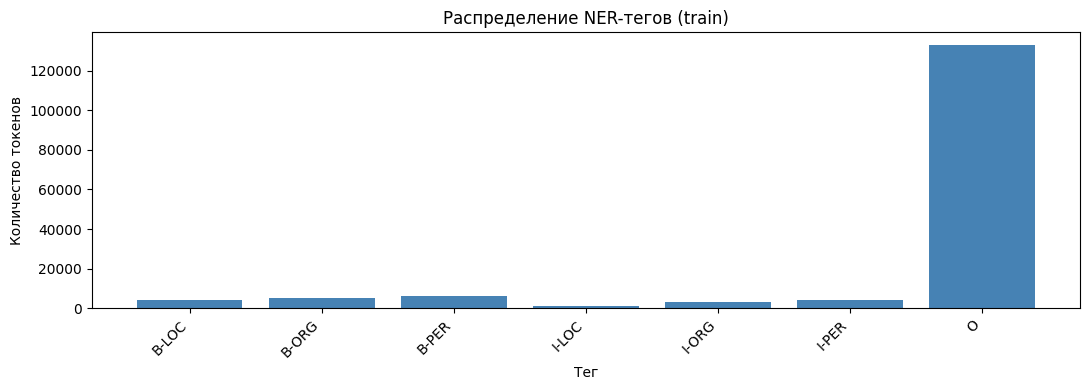


Количество токенов по тегам:
  B-LOC: 4,335
  B-ORG: 5,084
  B-PER: 6,359
  I-LOC: 972
  I-ORG: 3,227
  I-PER: 3,925
  O: 132,788


In [ ]:
all_tags = [id2label[t] for sample in ds["train"] for t in sample["ner_tags"]]
counts   = Counter(all_tags)

labels_sorted = sorted(counts.keys())
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(labels_sorted, [counts[l] for l in labels_sorted], color="steelblue")
ax.set_title("Распределение NER-тегов (train)")
ax.set_xlabel("Тег")
ax.set_ylabel("Количество токенов")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\nКоличество токенов по тегам:")
for l in labels_sorted:
    print(f"  {l}: {counts[l]:,}")

## 2. Подготовка данных: токенизация и выравнивание меток

In [ ]:
# import time
# from IPython import get_ipython

# _t = {}

# def _pre(info):  _t["start"] = time.perf_counter()
# def _post(info):
#     if "start" in _t:
#         print(f"⏱ {time.perf_counter() - _t['start']:.2f} s")

# ip = get_ipython()
# ip.events.register("pre_run_cell", _pre)
# ip.events.register("post_run_cell", _post)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
print(f"Токенизатор: {tokenizer.__class__.__name__}")
print(f"Vocab size:  {tokenizer.vocab_size:,}")

ex = ds["train"][0]
enc = tokenizer(ex["tokens"], is_split_into_words=True, truncation=True, max_length=MAX_LENGTH)
print(f"\nПример: {ex['tokens'][:]}")
print(f"Теги:   {[id2label[t] for t in ex['ner_tags'][:]]}")
print(f"→ {tokenizer.convert_ids_to_tokens(enc['input_ids'][:])}")

Токенизатор: BertTokenizer
Vocab size:  119,547

Пример: ['"', 'Если', 'Миронов', 'занял', 'столь', 'оппозиционную', 'позицию', ',', 'то', 'мне', 'представляется', ',', 'что', 'для', 'него', 'было', 'бы', 'порядочным', 'и', 'правильным', 'уйти', 'в', 'отставку', 'с', 'занимаемого', 'им', 'поста', ',', 'поста', ',', 'который', 'предоставлен', 'ему', 'сегодня', '"', 'Единой', 'Россией', "''", 'и', 'никем', 'больше', "''", ',', '-', 'заключает', 'Исаев', '.']
Теги:   ['O', 'O', 'B-PER', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-ORG', 'I-ORG', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-PER', 'O']
→ ['[CLS]', '"', 'Если', 'Миронов', 'занял', 'столь', 'оппозиционную', 'позицию', ',', 'то', 'мне', 'представляется', ',', 'что', 'для', 'него', 'было', 'бы', 'поряд', '##очным', 'и', 'правильным', 'уйти', 'в', 'отставку', 'с', 'заним', '##аемого', 'им', 'поста', ',', 'поста', '

In [ ]:
def tokenize_and_align_labels(examples):
    tokenized = tokenizer(
        examples["tokens"],
        is_split_into_words=True,
        truncation=True,
        max_length=MAX_LENGTH,
    )
    aligned = []
    for i, tags in enumerate(examples["ner_tags"]):
        word_ids  = tokenized.word_ids(batch_index=i)
        prev_word = None
        row       = []
        for wid in word_ids:
            if wid is None:
                row.append(-100)          # [CLS] / [SEP]
            elif wid != prev_word:
                row.append(tags[wid])     # первый субтокен слова
            else:
                row.append(-100)          # продолжение слова — игнорируем
            prev_word = wid
        aligned.append(row)
    tokenized["labels"] = aligned
    return tokenized

⏱ 0.01 s


In [ ]:
tokenized_ds = ds.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=ds["train"].column_names,
)
print(tokenized_ds)

Map:   0%|          | 0/7746 [00:00<?, ? examples/s]

Map:   0%|          | 0/2582 [00:00<?, ? examples/s]

Map:   0%|          | 0/2582 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 7746
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 2582
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 2582
    })
})
⏱ 6.20 s


## 3. Бейзлайн — Natasha NER

In [ ]:
seqeval_metric = evaluate.load("seqeval")

entity_types_ds = {l.split("-")[1] for l in label_names if "-" in l}
print("Типы сущностей в датасете:", entity_types_ds)

NATASHA_TYPES = {"PER", "ORG", "LOC"}
EVAL_TYPES    = NATASHA_TYPES & entity_types_ds
print("Оцениваем по типам:     ", EVAL_TYPES)

Типы сущностей в датасете: {'LOC', 'PER', 'ORG'}
Оцениваем по типам:      {'LOC', 'PER', 'ORG'}
⏱ 1.23 s


In [ ]:
segmenter  = Segmenter()
emb        = NewsEmbedding()
ner_tagger = NewsNERTagger(emb)

def normalize_text(s):
    s = s.replace("\u00ad", "").replace("\u200b", "")
    return re.sub(r"\s+", " ", s).strip()

def tokens_to_text_offsets(tokens):
    parts, offsets, cur = [], [], 0
    for i, t in enumerate(tokens):
        if i > 0:
            parts.append(" ")
            cur += 1
        offsets.append((cur, cur + len(t)))
        parts.append(t)
        cur += len(t)
    return normalize_text("".join(parts)), offsets

def natasha_spans(text):
    doc = Doc(text)
    doc.segment(segmenter)
    doc.tag_ner(ner_tagger)
    return [(s.start, s.stop, s.type) for s in doc.spans]

def char_spans_to_bio(tokens, offsets, char_spans, valid_types):
    labels = ["O"] * len(tokens)
    for cs, ce, typ in sorted(char_spans, key=lambda x: (x[0], -(x[1] - x[0]))):
        if typ not in valid_types:
            continue
        covered = [i for i, (ts, te) in enumerate(offsets) if ts >= cs and te <= ce]
        if not covered:
            continue
        labels[covered[0]] = "B-" + typ
        for i in covered[1:]:
            labels[i] = "I-" + typ
    return labels

def filter_to_types(bio_labels, valid_types):
    return [
        l if l == "O" or l.split("-")[1] in valid_types else "O"
        for l in bio_labels
    ]

⏱ 1.16 s


In [ ]:
def run_natasha(split, limit=500):
    y_true, y_pred = [], []
    for i in range(min(limit, len(split))):
        ex     = split[i]
        tokens = ex["tokens"]
        gold   = filter_to_types([id2label[t] for t in ex["ner_tags"]], EVAL_TYPES)
        text, offsets = tokens_to_text_offsets(tokens)
        spans  = natasha_spans(text)
        pred   = char_spans_to_bio(tokens, offsets, spans, EVAL_TYPES)
        y_true.append(gold)
        y_pred.append(pred)
    return y_true, y_pred

print("Запускаем Natasha на test (500 примеров)...")
y_true_nat, y_pred_nat = run_natasha(ds["test"], limit=500)
res_nat = seqeval_metric.compute(
    predictions=y_pred_nat, references=y_true_nat, zero_division=0
)
print(f"\nNatasha — F1: {res_nat['overall_f1']:.4f}  "
      f"P: {res_nat['overall_precision']:.4f}  "
      f"R: {res_nat['overall_recall']:.4f}")

results = {}
results["Natasha (baseline)"] = {
    "f1":        round(res_nat["overall_f1"], 4),
    "precision": round(res_nat["overall_precision"], 4),
    "recall":    round(res_nat["overall_recall"], 4),
}
pd.DataFrame([{"model": k, **v} for k, v in results.items()])

Запускаем Natasha на test (500 примеров)...

Natasha — F1: 0.8985  P: 0.9248  R: 0.8736


,model,f1,precision,recall
0,Natasha (baseline),0.8985,0.9248,0.8736


⏱ 7.10 s


## 4. Дообучение энкодера на NER

1. **Разогрев** — замораживаем encoder, обучаем только NER-голову (`lr=5e-4`) (чтобы получить +- разумные градиенты)
2. **Полное дообучение** — размораживаем всё (`lr=2e-5`)

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    y_true, y_pred = [], []
    for p_row, l_row in zip(preds, labels):
        true_row, pred_row = [], []
        for p, l in zip(p_row, l_row):
            if l == -100:
                continue
            true_row.append(id2label[l])
            pred_row.append(id2label[p])
        y_true.append(true_row)
        y_pred.append(pred_row)
    res = seqeval_metric.compute(
        predictions=y_pred, references=y_true, zero_division=0
    )
    return {
        "f1":        res["overall_f1"],
        "precision": res["overall_precision"],
        "recall":    res["overall_recall"],
    }

data_collator = DataCollatorForTokenClassification(
    tokenizer=tokenizer, padding="longest"
)

⏱ 0.00 s


In [ ]:
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_ID,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
)
print(f"Параметров всего: {model.num_parameters():,}")

pytorch_model.bin:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                          

Параметров всего: 177,268,231
⏱ 11.22 s


In [ ]:
# Этап 1: обучаем только голову (encoder заморожен)
for p in model.base_model.parameters():
    p.requires_grad = False

args_warmup = TrainingArguments(
    output_dir=NER_OUTPUT_DIR + "_warmup",
    learning_rate=5e-4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=5, # возьмем немного эпох
    fp16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=50,
    save_total_limit=1,
    report_to="none",
)

trainer_warmup = Trainer(
    model=model,
    args=args_warmup,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer_warmup.train()

Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,0.251196,0.179042,0.723819,0.772518,0.680896
2,0.156706,0.126790,0.808930,0.809478,0.808383
3,0.132185,0.109933,0.830067,0.817926,0.842573
4,0.128075,0.102919,0.841426,0.826533,0.856867
5,0.117768,0.100661,0.843234,0.828763,0.858219


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1215, training_loss=0.19637985602327826, metrics={'train_runtime': 165.7031, 'train_samples_per_second': 233.731, 'train_steps_per_second': 7.332, 'total_flos': 1254966043420716.0, 'train_loss': 0.19637985602327826, 'epoch': 5.0})

⏱ 169.89 s


In [ ]:
# Этап 2: полное дообучение (encoder разморожен)
for p in model.base_model.parameters():
    p.requires_grad = True

args_ft = TrainingArguments(
    output_dir=NER_OUTPUT_DIR,
    learning_rate=2e-5,
    per_device_train_batch_size=8, # меньше, чем в прошлой ячейке, так как обучаемых весов больше
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=4, # чтобы эффективный размер батча был как в предыдущей ячейке
    num_train_epochs=10,
    fp16=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=50,
    save_total_limit=2,
    warmup_ratio=0.1,
    weight_decay=0.01,
    max_grad_norm=1.0,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=args_ft,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)
trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,0.129814,0.025095,0.963191,0.960969,0.965424
2,0.060884,0.015704,0.976614,0.973149,0.980104
3,0.032709,0.019314,0.982176,0.979815,0.984547
4,0.017710,0.017993,0.979784,0.976588,0.983002
5,0.017418,0.020352,0.980332,0.978633,0.982036
6,0.003544,0.021829,0.981583,0.979977,0.983195


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1458, training_loss=0.06111975128421322, metrics={'train_runtime': 577.3662, 'train_samples_per_second': 134.161, 'train_steps_per_second': 4.209, 'total_flos': 1125952082842488.0, 'train_loss': 0.06111975128421322, 'epoch': 6.0})

⏱ 577.73 s


In [ ]:
preds_ner = trainer.predict(tokenized_ds["test"])
m = preds_ner.metrics
print(f"NER fine-tuned — F1: {m['test_f1']:.4f}  "
      f"P: {m['test_precision']:.4f}  "
      f"R: {m['test_recall']:.4f}")

results["RuBERT NER (fine-tuned)"] = {
    "f1":        round(m["test_f1"], 4),
    "precision": round(m["test_precision"], 4),
    "recall":    round(m["test_recall"], 4),
}
pd.DataFrame([{"model": k, **v} for k, v in results.items()])

NER fine-tuned — F1: 0.9832  P: 0.9806  R: 0.9859


,model,f1,precision,recall
0,Natasha (baseline),0.8985,0.9248,0.8736
1,RuBERT NER (fine-tuned),0.9832,0.9806,0.9859


⏱ 3.70 s


## 5. MLM предобучение → NER дообучение

Адаптируем модель к домену датасета через MLM с маскированием целых слов, затем дообучаем на NER.

In [ ]:
del model, trainer, trainer_warmup
gc.collect()
if device == "cuda":
    torch.cuda.empty_cache()
print("Память освобождена.")

In [ ]:
def tokens_to_text_batch(examples):
    return {"text": [" ".join(toks) for toks in examples["tokens"]]}

text_ds = ds["train"].map(
    tokens_to_text_batch,
    batched=True,
    remove_columns=ds["train"].column_names,
)
print(f"Текстовый датасет для MLM: {len(text_ds)} примеров")
print("Пример:", text_ds[0]["text"][:80])

Map:   0%|          | 0/7746 [00:00<?, ? examples/s]

Текстовый датасет для MLM: 7746 примеров
Пример: " Если Миронов занял столь оппозиционную позицию , то мне представляется , что д
⏱ 0.22 s


In [ ]:
def tokenize_mlm(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LENGTH,
        # return_special_tokens_mask=True,  # нужен DataCollatorForWholeWordMask
    )

mlm_tokenized = text_ds.map(
    tokenize_mlm,
    batched=True,
    remove_columns=["text"],
)
print(mlm_tokenized)

Map:   0%|          | 0/7746 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 7746
})
⏱ 0.97 s


In [ ]:
mlm_model = AutoModelForMaskedLM.from_pretrained(MODEL_ID)
print(f"MLM модель, параметров: {mlm_model.num_parameters():,}")

# Маскируем целые слова (по ## в BERT-токенайзере)
# wwm_collator = DataCollatorForWholeWordMask(
#     tokenizer=tokenizer,
#     mlm=True,
#     mlm_probability=0.15,
# )

from transformers import DataCollatorForLanguageModeling

wwm_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.15,
)

Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie bert.embeddings.word_embeddings.weight to cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BertForMaskedLM LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.pooler.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight  | UNEXPECTED |  | 
cls.seq_relationship.bias    | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
bert.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be igno

MLM модель, параметров: 269,906,166
⏱ 1.81 s


In [ ]:
mlm_args = TrainingArguments(
    output_dir=MLM_OUTPUT_DIR,
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    fp16=False,
    save_strategy="epoch",
    logging_steps=100,
    save_total_limit=1,
    warmup_ratio=0.06,
    weight_decay=0.01,
    report_to="none",
)

mlm_trainer = Trainer(
    model=mlm_model,
    args=mlm_args,
    train_dataset=mlm_tokenized,
    data_collator=wwm_collator,
    processing_class=tokenizer,
)

mlm_trainer.train()
mlm_trainer.save_model(MLM_OUTPUT_DIR + "/best")
print("MLM предобучение завершено!")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss
100,1.718889
200,1.757253
300,1.818864
400,1.779860
500,1.838659
600,1.646076
700,1.633940
800,1.655055
900,1.651308
1000,1.582955


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

MLM предобучение завершено!
⏱ 662.99 s


In [ ]:
del mlm_model, mlm_trainer
gc.collect()
print("Память освобождена.")

Память освобождена.
⏱ 0.35 s


In [ ]:
mlm_ner_model = AutoModelForTokenClassification.from_pretrained(
    MLM_OUTPUT_DIR + "/best",
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,  # NER-головау инициализируем заново
)
print(f"MLM\u2192NER модель, параметров: {mlm_ner_model.num_parameters():,}")

args_mlm_ner = TrainingArguments(
    output_dir=NER_MLM_OUTPUT_DIR,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=4,
    num_train_epochs=10,
    fp16=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=50,
    save_total_limit=2,
    warmup_ratio=0.1,
    weight_decay=0.01,
    max_grad_norm=1.0,
    report_to="none",
)

trainer_mlm_ner = Trainer(
    model=mlm_ner_model,
    args=args_mlm_ner,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)
trainer_mlm_ner.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: rubert_wwm_mlm/best
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be

MLM→NER модель, параметров: 177,268,231


Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,0.181221,0.032359,0.957333,0.944204,0.970833
2,0.069341,0.017589,0.972822,0.970764,0.974889
3,0.045022,0.020940,0.977058,0.975178,0.978945
4,0.019740,0.020713,0.978288,0.977439,0.979138
5,0.020506,0.019384,0.979871,0.977142,0.982615
6,0.009103,0.022072,0.979183,0.977111,0.981263
7,0.005424,0.023265,0.981194,0.979777,0.982615
8,0.002954,0.024965,0.979938,0.978617,0.981263
9,0.005126,0.025136,0.980426,0.978822,0.982036
10,0.003586,0.024335,0.981103,0.979403,0.982809


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,0.181221,0.032359,0.957333,0.944204,0.970833
2,0.069341,0.017589,0.972822,0.970764,0.974889
3,0.045022,0.020940,0.977058,0.975178,0.978945
4,0.019740,0.020713,0.978288,0.977439,0.979138
5,0.020506,0.019384,0.979871,0.977142,0.982615
6,0.009103,0.022072,0.979183,0.977111,0.981263
7,0.005424,0.023265,0.981194,0.979777,0.982615
8,0.002954,0.024965,0.979938,0.978617,0.981263
9,0.005126,0.025136,0.980426,0.978822,0.982036
10,0.003586,0.024335,0.981103,0.979403,0.982809


TrainOutput(global_step=2430, training_loss=0.18903656691128826, metrics={'train_runtime': 1491.2737, 'train_samples_per_second': 51.942, 'train_steps_per_second': 1.629, 'total_flos': 1876161838068012.0, 'train_loss': 0.18903656691128826, 'epoch': 10.0})

⏱ 1492.45 s


In [ ]:
preds_mlm_ner = trainer_mlm_ner.predict(tokenized_ds["test"])
m2 = preds_mlm_ner.metrics
print(f"WWM-MLM \u2192 NER — F1: {m2['test_f1']:.4f}  "
      f"P: {m2['test_precision']:.4f}  "
      f"R: {m2['test_recall']:.4f}")

results["RuBERT WWM-MLM \u2192 NER"] = {
    "f1":        round(m2["test_f1"], 4),
    "precision": round(m2["test_precision"], 4),
    "recall":    round(m2["test_recall"], 4),
}
pd.DataFrame([{"model": k, **v} for k, v in results.items()])

WWM-MLM → NER — F1: 0.9829  P: 0.9816  R: 0.9841


,model,f1,precision,recall
0,Natasha (baseline),0.8985,0.9248,0.8736
1,RuBERT NER (fine-tuned),0.9832,0.9806,0.9859
2,RuBERT WWM-MLM → NER,0.9829,0.9816,0.9841


⏱ 10.31 s


## 6. Сравнение результатов

                  model     f1  precision  recall
     Natasha (baseline) 0.8985     0.9248  0.8736
RuBERT NER (fine-tuned) 0.9832     0.9806  0.9859
   RuBERT WWM-MLM → NER 0.9829     0.9816  0.9841


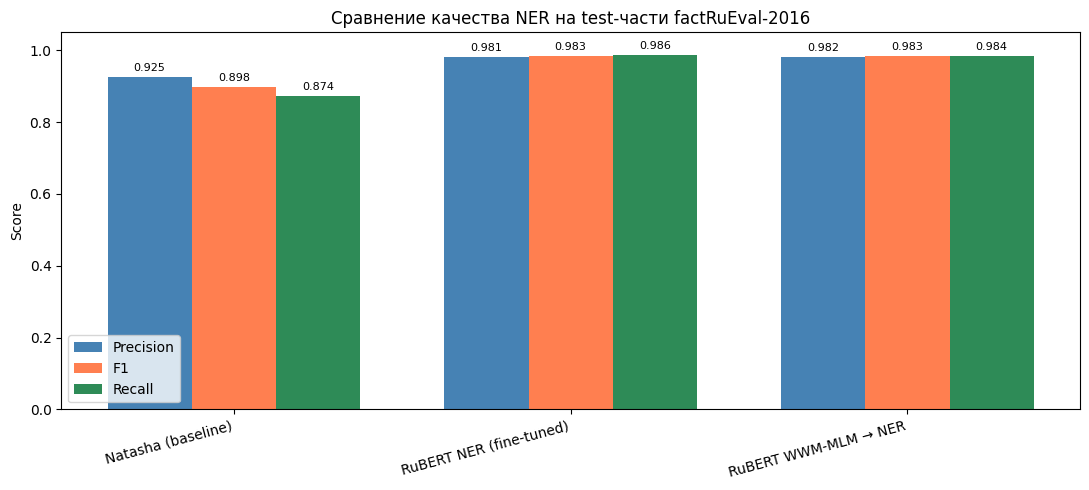

⏱ 0.20 s


In [ ]:
df = pd.DataFrame([{"model": k, **v} for k, v in results.items()])
df = df.round(4)
print(df.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
x     = np.arange(len(df))
width = 0.25

b1 = ax.bar(x - width, df["precision"], width, label="Precision", color="steelblue")
b2 = ax.bar(x,          df["f1"],        width, label="F1",        color="coral")
b3 = ax.bar(x + width, df["recall"],    width, label="Recall",    color="seagreen")

for bar in (*b1, *b2, *b3):
    h = bar.get_height()
    ax.annotate(
        f"{h:.3f}",
        xy=(bar.get_x() + bar.get_width() / 2, h),
        xytext=(0, 3), textcoords="offset points",
        ha="center", va="bottom", fontsize=8,
    )

ax.set_title("Сравнение качества NER на test-части factRuEval-2016")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(df["model"], rotation=15, ha="right")
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

## 7. Выводы

### Результаты

| Модель | Особенности | F1 |
|---|---|---|
| Natasha (baseline) | Правиловый NER, не обучался на датасете | 0.8985 |
| RuBERT NER (fine-tuned) | Дообучен на train-части | 0.9832 |
| RuBERT WWM-MLM → NER | MLM адаптация к домену + NER | 0.9829 |

### Наблюдения

1. **Fine-tuning даёт значительный прирост над бейзлайном**

RuBERT после дообучения превосходит Natasha на +8.5 пп F1 (0.8985 → 0.9832). Это ожидаемо: модель обучилась именно на разметке factRuEval и точно знает какие сущности и в каком стиле размечать.

2. **MLM предобучение не дало прироста**

RuBERT WWM-MLM → NER (0.9829) практически идентичен прямому fine-tuning (0.9832) — разница в пределах статистической погрешности (-0.0003 F1). Это может объясняться тем, что датасет для доменной адаптации слишком мал.

3. **Бейзлайн Natasha показывает неплохие метрики**

Это может быть связано с тем, что factRuEval содержит стандартные новостные сущности, на которых Natasha и обучалась.